
# Week 1 – Exploratory Data Analysis (EDA)

Dataset used: **Titanic dataset**  



## Day 1 – Program Orientation & Data Understanding

### Learning Objectives
- Understand the role of EDA in Data Science
- Load and inspect datasets
- Understand data types, schema, and business context



### 1. What is EDA?


In [ ]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")


### 2. Loading the Dataset

In [ ]:
url = "titanic.csv"
df = pd.read_csv(url)
df.head()

,Unnamed: 0,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.drop(columns=['Unnamed: 0'], inplace=True)


### 3. Dataset Overview
Key questions:
- How many rows & columns?
- What does each column represent?


In [ ]:

df.shape


(891, 12)

In [ ]:

df.columns


Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [ ]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



### 4. Understanding Data Types
- Numerical vs Categorical
- Continuous vs Discrete


In [ ]:

df.dtypes


PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


### Exercise
1. Identify numerical and categorical columns
2. Which column could be the target?
3. Which columns might leak information?



## Day 2 – Relationship Analysis (4.5 hrs)

### Learning Objectives
- Perform univariate analysis
- Perform bivariate & multivariate analysis
- Interpret visualizations


### 1. Univariate Analysis
Examines a single variable at a time to describe its distribution, central tendency (mean, median, mode), and variability

In [ ]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


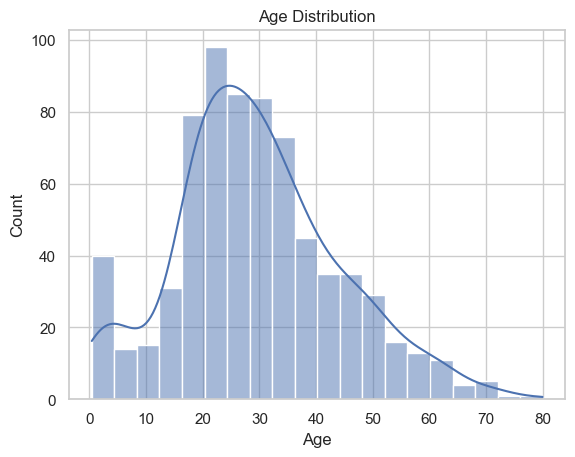

In [ ]:
sns.histplot(df["Age"], kde=True)
plt.title("Age Distribution")
plt.show()


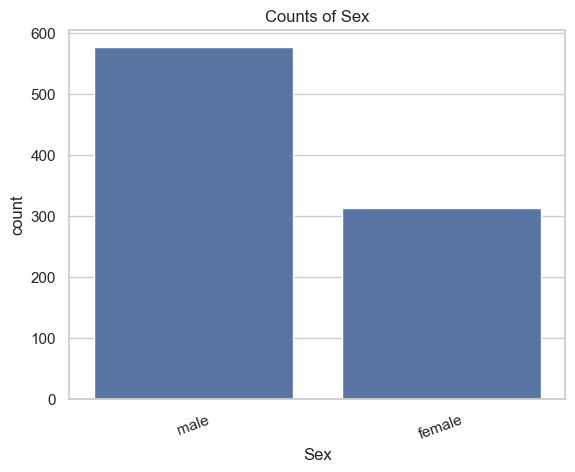

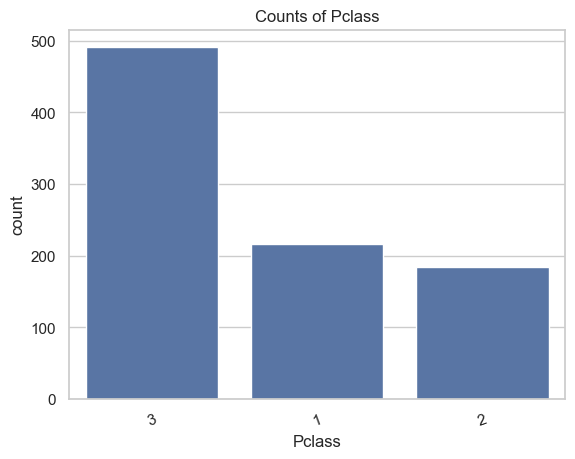

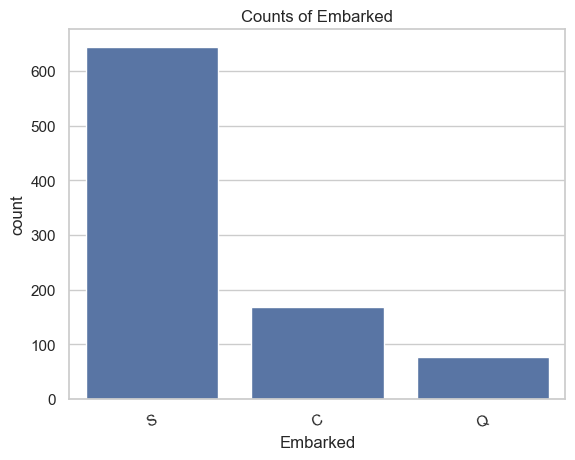

In [ ]:

# Categorical distributions
for c in ["Sex", "Pclass", "Embarked"]:
    plt.figure()
    sns.countplot(x=c, data=df, order=df[c].value_counts().index)
    plt.title(f"Counts of {c}")
    plt.xticks(rotation=20)
    plt.show()


### 2. Bivariate Analysis
Examines the relationship between exactly two variables, determining the strength and direction of their association

In [ ]:
target = "Survived"
df[target].value_counts(normalize=True)

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

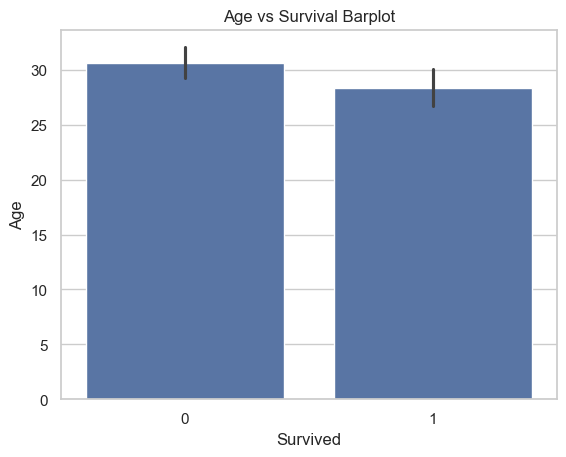

In [ ]:
sns.barplot(x="Survived", y="Age", data=df)
plt.title("Age vs Survival Barplot")
plt.show()


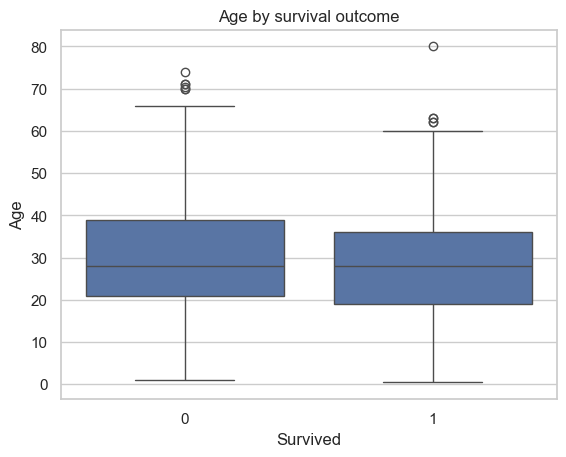

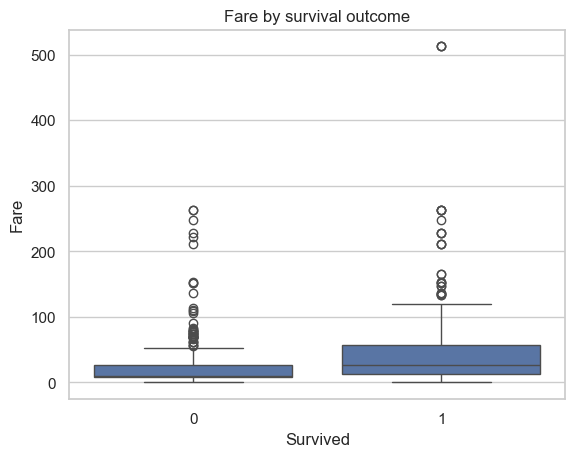

In [ ]:
# Numeric feature vs target
for c in ["Age", "Fare"]:
    plt.figure()
    sns.boxplot(x=target, y=c, data=df)
    plt.title(f"{c} by survival outcome")
    plt.show()


### 3. Multivariate Analysis
Used to analyze data with more than two variables simultaneously, aiming to uncover complex patterns, relationships, and dependencies that univariate or bivariate methods miss, providing a more comprehensive understanding of the underlying structure

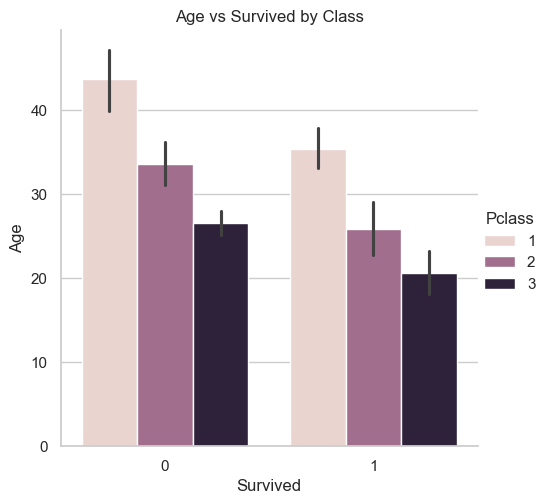

In [ ]:
sns.catplot(x="Survived", y="Age", hue="Pclass", kind="bar", data=df)
plt.title('Age vs Survived by Class')
plt.show()

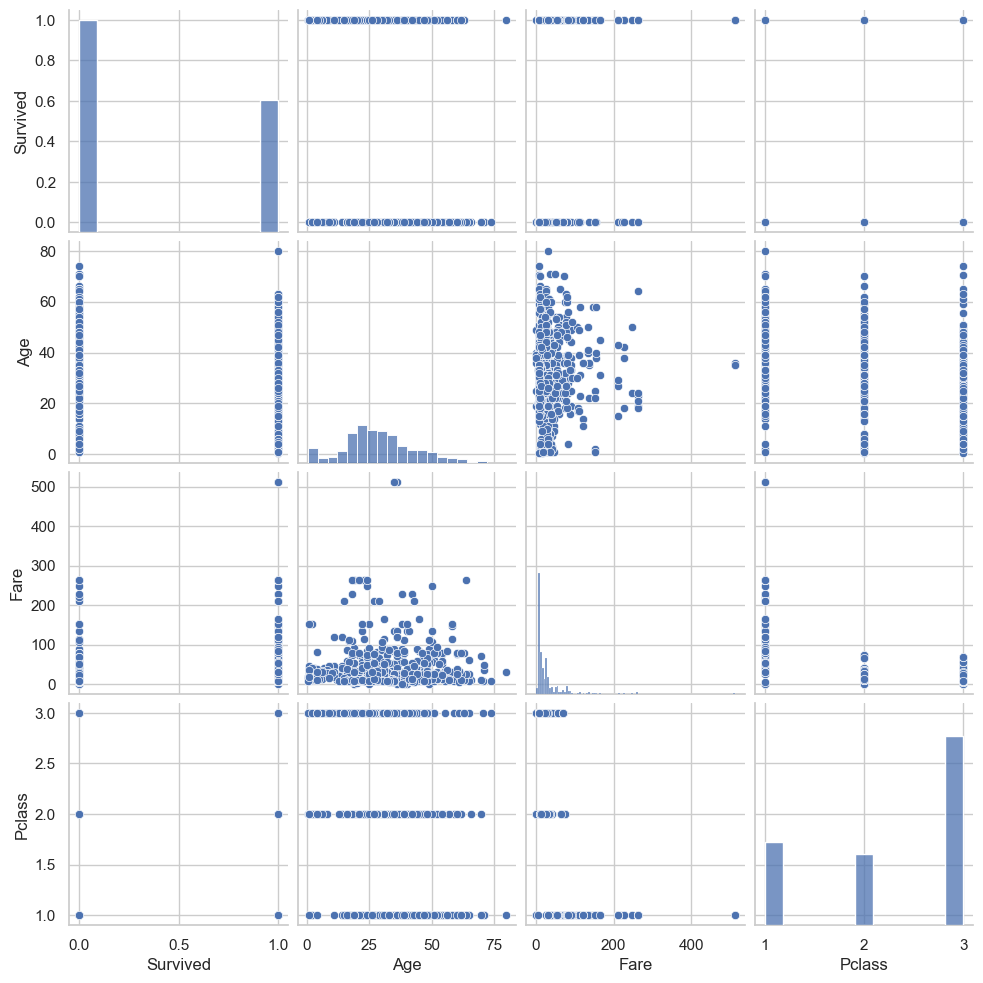

In [ ]:
sns.pairplot(df[['Survived','Age','Fare','Pclass']])
plt.show()

## 4. Outliers
Outliers can:
 - Inflate or hide correlations
 - Stretch axes and hide patterns
 - Dominate model coefficients
We must see them before we decide what to do.

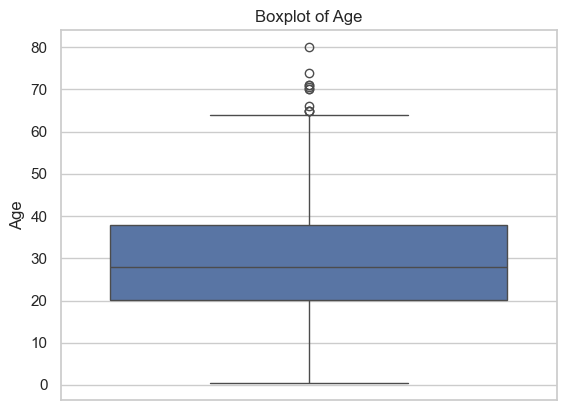

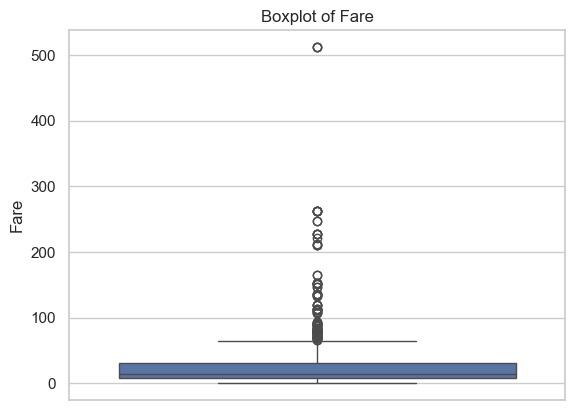

In [ ]:
# Boxplots to surface outliers
for c in ["Age", "Fare"]:
    plt.figure()
    sns.boxplot(y=df[c])
    plt.title(f"Boxplot of {c}")
    plt.show()


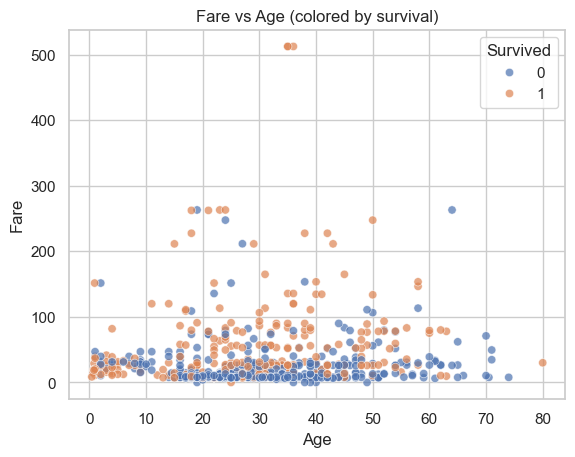

In [ ]:
# Scatter plot to show bivariate outliers
plt.figure()
sns.scatterplot(x="Age", y="Fare", hue="Survived", data=df, alpha=0.7)
plt.title("Fare vs Age (colored by survival)")
plt.show()
